In [1]:
print("gg")

gg


In [2]:
!pip install -q efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.7 MB/s eta 0:00:00


In [3]:
import tensorflow as tf

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

# Memory optimization
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Mixed precision (BOOST SPEED)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("GPU READY 🚀")

2026-04-04 15:53:01.251731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775317981.453642      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775317981.517855      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775317982.020612      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775317982.020652      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775317982.020655      24 computation_placer.cc:177] computation placer alr

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU READY 🚀


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [5]:
DATA_DIR = "/kaggle/input/datasets/dollyprajapati182/fer2013-balance-dataset"

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [7]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 45304 images belonging to 7 classes.
Found 11326 images belonging to 7 classes.
Found 6286 images belonging to 7 classes.


In [8]:
print("Train classes:", train_gen.class_indices)
print("Val classes:", val_gen.class_indices)
print("Test classes:", test_gen.class_indices)

Train classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Val classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Test classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [9]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Fine-tuning last layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(7, activation='softmax', dtype='float32')(x)

model = models.Model(inputs=base_model.input, outputs=output)

I0000 00:00:1775318052.750372      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775318052.756400      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, CSVLogger, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_emotion_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True,
                    mode='max',
                    verbose=1),
    CSVLogger('/kaggle/working/training_log.csv')
]

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1775318093.922105      97 service.cc:152] XLA service 0x77fa5c2346f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775318093.922151      97 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775318093.922156      97 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775318101.749514      97 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-04 15:56:13.911088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 15:56:14.056089: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 15:56:22.039569: E external/local_xl

 99/708 ━━━━━━━━━━━━━━━━━━━━ 11:06 1s/step - accuracy: 0.1807 - loss: 2.9739

2026-04-04 16:00:35.008277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 16:00:35.158732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 16:00:43.621761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 16:00:43.773923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 16:00:43.958833: E external/local_xla/xla/stream_

708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2668 - loss: 2.5225
Epoch 1: val_accuracy improved from -inf to 0.46389, saving model to /kaggle/working/best_emotion_model.keras
708/708 ━━━━━━━━━━━━━━━━━━━━ 1303s 2s/step - accuracy: 0.2669 - loss: 2.5221 - val_accuracy: 0.4639 - val_loss: 1.5596 - learning_rate: 1.0000e-04
Epoch 2/25
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.4809 - loss: 1.6217
Epoch 2: val_accuracy improved from 0.46389 to 0.58873, saving model to /kaggle/working/best_emotion_model.keras
708/708 ━━━━━━━━━━━━━━━━━━━━ 660s 932ms/step - accuracy: 0.4809 - loss: 1.6216 - val_accuracy: 0.5887 - val_loss: 1.4256 - learning_rate: 1.0000e-04
Epoch 3/25
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.5563 - loss: 1.4447
Epoch 3: val_accuracy improved from 0.58873 to 0.62502, saving model to /kaggle/working/best_emotion_model.keras
708/708 ━━━━━━━━━━━━━━━━━━━━ 671s 948ms/step - accuracy: 0.5563 - loss: 1.4447 - val_accuracy: 0.6250 - val_loss: 1.27

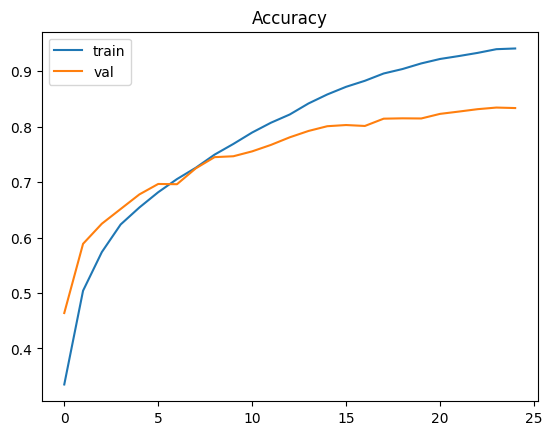

In [13]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [14]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

99/99 ━━━━━━━━━━━━━━━━━━━━ 93s 945ms/step - accuracy: 0.8320 - loss: 0.8683
Test Accuracy: 0.8278714418411255


99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 315ms/step


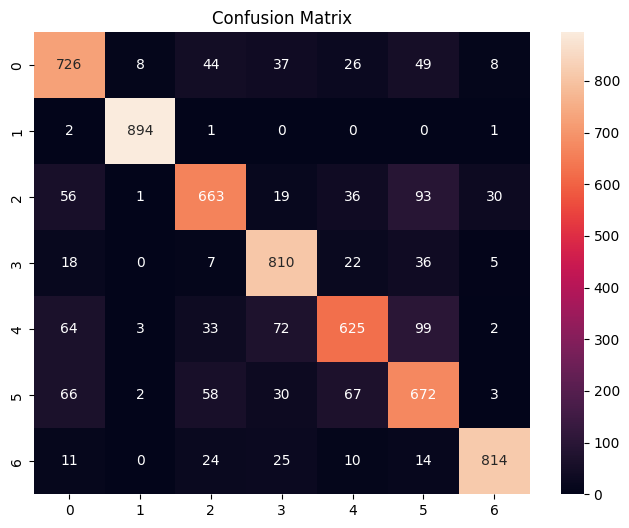

In [15]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       898
           1       0.98      1.00      0.99       898
           2       0.80      0.74      0.77       898
           3       0.82      0.90      0.86       898
           4       0.80      0.70      0.74       898
           5       0.70      0.75      0.72       898
           6       0.94      0.91      0.92       898

    accuracy                           0.83      6286
   macro avg       0.83      0.83      0.83      6286
weighted avg       0.83      0.83      0.83      6286



In [17]:
model.save("/kaggle/working/emotion_model.h5")